Próximos passos: "Responder: posso usar um filtro global ou precisa ser individual?"   

fazer N sinais, embaralhar e 'dar' a divisao dos sinais pra cada wave/canal

P1) Filtro pra cada canal + media dos pesos
1. Fazer um filtro (calc pesos) pra cada canal, e ter tantos filtros qnt canais
2. Aplicar em cada saida para ter tantas reconstruções qnt canis (msm qntd)
3. Fazer média dos pesos de todos os canais
4. Aplicar esses pesos em todos os canais

P2) Filtro so com base no canal ideal 
1. Calcular peso so com canal ideal
2. Aplicar esses pesos em todos os canais

P3) Comparar resultados com RMSE

P4) 

# INIT

In [108]:
# Bibliotecas
from Filtro_LS import filtro_LS0
from Filtro_LS import filtro_LS1
from Filtro_LS import filtro_LS10
from numpy.linalg import pinv as inversa
from Funcoes_auxiliares import *
import os
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import Eq
from sympy import fraction
from sympy.abc import s
from scipy import signal
import random
from numpy import convolve as np_conv
from scipy.signal import convolve as scipy_conv

# from datetime import datetime
# from scipy.stats import pearsonr
# from matplotlib.patches import Ellipse
# from Gerador_de_Sinais_copy import *
# from Gerador_de_Sinais import main as leitura_shaper
# from Gerador_de_Sinais import original_signal_generator

In [2]:
# Gerador/Simulador do sinal registrado pelos sensores #
def original_signal_generator(
    num_amostras_leitura: int,
    position_percentage: float = 0.2,
    media_energia_cintilador: int = 30,
    seed: int | None = None,
):
    """
    position_percentage = 20 a 30 % de num_amostras_leitura
    """
    rng = np.random.default_rng(seed)

    signal = np.zeros(num_amostras_leitura)

    # Sortear indices de signal
    position = int(position_percentage * num_amostras_leitura)

    indx = rng.permutation(len(signal))[:position]
    signal[indx] = rng.exponential(media_energia_cintilador, size=len(indx)).astype(int)

    "Forma antes d mudar para usar o seed"
    # As posições
    # indx = np.random.permutation(len(signal))[:position]
    # As posições com as devidas energias
    # signal[indx] = np.random.exponential(
    #     media_energia_cintilador, size=len(indx)
    # ).astype(int)

    return signal


# Shaper Simulator
def CKTs_parameters():

    ## Definition of constants ##
    tau_1, tau_2, Vo, Vi = sp.symbols("tau_1 tau_2 Vo Vi")
    CC0, C1, C2, C3 = sp.symbols("CC0 C1 C2 C3")
    RL = sp.symbols("RL")
    L1, L2, L3 = sp.symbols("L1 L2 L3")
    I1, I2, I3, I4 = sp.symbols("I1 I2 I3 I4")

    # Ckt components in order
    Cord = [CC0, C1, C2, C3, L1, L2, L3, RL]  # , tau_1, tau_2]

    # Nominal values (old values) of Cord elements in order
    Cval = [
        100e-9,  # CC0
        120e-12,  # Ca = C1
        130e-12,  # Cb = C3 + C2
        83e-12,  # Cc = C5 + C4
        2.48e-6,  # La = L1 + L2
        1.6e-6,  # Lb = L3 + L4
        0.78e-6,  # Lc = L5 + L6
        138.8338,  # RL = (R1 + R2) //  R3
        # 3.1046e-09,  # tau_2
        # 6.5798e-09,  # tau_1
    ]
    tau_1, tau_2 = 3.1046e-09, 6.5798e-09

    # Ckt equations
    eqn1 = Eq(I1 / (CC0 * s) + (I1 - I2) / (C1 * s), Vi)
    eqn2 = Eq((I2 - I3) / (C2 * s) - (I1 - I2) / (C1 * s) + L1 * s * I2, 0)
    eqn3 = Eq((I3 - I4) / (C3 * s) - (I2 - I3) / (C2 * s) + L2 * s * I3, 0)
    eqn4 = Eq(I4 * RL - (I3 - I4) / (C3 * s) + L3 * s * I4, 0)
    eqn5 = Eq(I4 * RL, Vo)

    eqns = [eqn1, eqn2, eqn3, eqn4, eqn5]

    # Solver
    Sol = sp.solve(eqns, (I1, I2, I3, I4, Vo))
    si6 = Sol[I4]

    # PMT
    PMT = (1 / tau_1 - 1 / tau_2) / (
        s**2 + (1 / tau_1 + 1 / tau_2) * s + 1 / tau_1 / tau_2
    )

    # I_out without V_in
    h = RL * si6 / Vi

    # Final transfer function
    H1 = PMT * h

    return H1, Cord, Cval


# gerador de pulsos/ondas
def MC_iteration(
    iterations,
    erro,
    components,
    nominal_values,
    FT,
    t,
    seed: int | None = None,
):
    """
    iter = 0 represents pure/error-free signal value
    MonteCarlo[0] = actual/error-free signal value

    FT: Transfer Function
    t1: time vector
    iterations: int
        number of iterations
    erro: percentage error of circuit components
    nominal_values: nominal values of circuit components

     seed: int | None
        Semente opcional para reprodutibilidade.
    """
    # print("Monte Carlo iteration")

    # Store all the poles of the iterations
    all_poles = []

    # Store the values ​​with error of each iteration
    MonteCarlo = []

    # Store all the FPs added of each iteration # list of all the graphs added with errors
    y_out = []

    # Helper to store the values ​​of y
    y1 = []

    # Seed para reprodutibilidade
    rng = random.Random(seed)

    for iter in range(iterations):

        # Random values; # error range; maximum error from -e% to +e%
        xa = []  # FP function of the summed iteration
        new_Cval = []  # List of components with changed values

        # Changing element values ​​without changing tau1 and tau2
        new_Cval = [
            (
                value * (rng.gauss(0, erro[idx])) + value
                if iter != 0 and idx < len(nominal_values) - 2
                else value
            )
            for idx, value in enumerate(nominal_values)
        ]

        # Saving component variations
        MonteCarlo.append(new_Cval[:-2])

        H = FT
        for variavel, v in zip(components, new_Cval):
            H = H.subs(variavel, v)

        # Separating numerator from denominator
        N_H, D_H = fraction(H)

        """RESIDUOS E POLOS"""

        coefs_num = []  # reset variable
        coefs_den = []  # reset variable

        coefs_num = sp.Poly(N_H, s).all_coeffs()  # get coefs
        coefs_den = sp.Poly(D_H, s).all_coeffs()  # get coefs

        # Frações parciais
        residuos, polos, b0 = [], [], []
        residuos, polos, b0 = signal.residue(coefs_num, coefs_den)

        # Saving all poles
        all_poles.append(polos)

        # Residual correction (removing the img part 0j from the real residuals)
        for polo1, residuo1 in zip(polos, residuos):
            if polo1.imag == 0:
                residuo1 = residuo1.real

        """LAPLACE INVERSA E GRAFICOS"""

        for enum, (polo, residuo) in enumerate(zip(polos, residuos)):

            # Check if the imaginary part is zero
            if polo.imag == 0:
                "EXPONENCIAIS"

                # Removing the img part (0j) of the real residues
                A = residuo.real
                d = polo.real
                x = A * np.exp(d * t)

                xa.append(x)

            else:
                "SENOS E COSSENOS"

                pol_1 = polos[enum - 1]  # conjugate

                if polo != pol_1 and polo != np.conjugate(pol_1):

                    a1 = polo.real
                    b1 = abs(polo.imag)

                    Mod = abs(residuos[enum])  # Modulo
                    fase = np.angle(residuos[enum])  # fase in rad

                    # FP term
                    x = 2 * Mod * np.exp(a1 * t) * np.cos(b1 * t + fase)

                    xa.append(x)

        "SUMMING THE TERMS"

        if iter != 0:
            y1 = sum(xa).real / maxs
            y_out.append(y1)

        else:
            sinal0 = sum(xa).real
            maxs = np.max(np.abs(sinal0))
            y1 = sinal0 / maxs  # largest module/ normalize
            y_out.append(y1)

    return y_out


# Chama a função degerador de ondas da devida maneira
def wave_former_main(
    num_canais: int,
    qntd_amostras: int,
    CKT_parameters: Callable | None,
    CKT_simulator: Callable | None,
    noise: int | float | list | np.ndarray = 0,
    parameters: dict | None = None,
    Seed: int | None = None,
):
    """# DOCSTRING REQUER ATUALIZAÇÃO

    Função para gerar a matriz de convolução de um circuito.
    A matriz resultate é qudrada (amostras_leitura x amostras_leitura).


    Parametros:
    -----------
    amostras_leitura: quantidade de amostras na leitura

    noise: erro/ruído associado a leitura do sinal para cada elemento do circuito. No caso d ser lista/array, deve ter o mesmo len() que Componentes, de CKT_parameters.

    CKT_parameters: parametros do circuito a ser simulado. Deve, obrigatoriamente, retornar 3 objetos/variaveis, nesta ordem:
        1. Função de transferência do circuito com as variaveis ainda a serem substituidas (funçao literal com o sympy),
        2. Componentes: Lista de variaveis do circuito como objeto sympy.symbols
        3. Valor_componentes: Lista dos valores dos componentes do circuito respeitando a ordem da variavel Componentes.

    parameters: Dicionario com as variáveis a serem desempacotadas para a função CKT_simulator().

    CKT_simulator: Função que faz a simulção do circuito.

    Return:
    -------
    Retorna os resultados da simulação do circuito de CKT_simulator().
    """

    # Parametros do CKT #

    TF, component, component_values = CKT_parameters()  # type: ignore[operator]

    # Parametros do gerador das formas de onda #
    if parameters is None:
        parametros_MC = {
            "iterations": num_canais,
            "t": np.arange(0, qntd_amostras) * 25 * 10**-9,
            "FT": TF,  # literal
            "erro": noise,  # Erro de cada elemento do circuito
            "components": component,
            "nominal_values": component_values,
            "seed": Seed,
        }

    return CKT_simulator(**parametros_MC)  # type: ignore[operator]


#

In [3]:
# Consantes & Variáveis #
qntd_canais = 3
qntd_leitura_por_canal = 4
amostras_por_leitura = 75
seed = 345

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 25.,  0.,  0.,  0.,
        33.,  0., 30.,  0., 96.,  0.,  7.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0., 27.,  0., 31.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 67.,
         0.,  0.,  0.,  0.,  0., 34.,  0., 69.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0., 83.,  0.,  0., 12.,  0.,  0.,  0.,  0., 16.,  0.,
         0., 35.,  0., 43.,  0.,  0.,  0.,  0.,  0.,  0.]),
 [<matplotlib.lines.Line2D at 0x164b96a4520>])

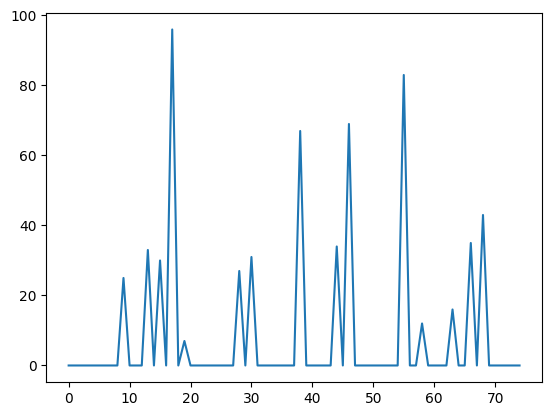

In [4]:
# Gerador de sinais #
sinais_originais = []

for canal in range(qntd_canais * qntd_leitura_por_canal):
    s_o = original_signal_generator(amostras_por_leitura, seed=seed + canal)
    sinais_originais.append(s_o)


sinais_originais[1], plt.plot(sinais_originais[1])

In [ ]:
print(len(sinais_originais), len(sinais_originais[1]))
"quantidade de sinais de entrada e quantidade de amostras de cada sinal de entrada"

In [5]:
# Ondas/resp aos pulsos gerados

ckt_parameters_error = (  # dois ultimos são tau1 e tau2
    np.array([10, 1, 1, 1, 2, 2, 2, 0.10, 0, 0], dtype=float)
) / 100


waves_por_canal = np.asarray(  # waves_por_canal[0] = sinal sem variação dos componentes
    wave_former_main(
        num_canais=qntd_canais,
        qntd_amostras=amostras_por_leitura,
        noise=ckt_parameters_error,
        CKT_parameters=CKTs_parameters,
        CKT_simulator=MC_iteration,
        Seed=seed,
    )
)

In [ ]:
# print(f"{len(sinais_originais), len(sinais_originais[0])}")
print(f"{len(waves_por_canal), len(waves_por_canal[0])}")
"quantidade de canal e amostras em cada canal"

# Filtros


In [ ]:
# Filtro 0 #
ordem_filtro0 = 7

sinal_estimado0 = filtro_LS0(
    sinal_desejado=sinais_originais[1],
    readout=leituras_canais["canal_1"][1],
    ordem_filter=ordem_filtro0,
    # delay=2,
)

plot_estimado_x_original(
    sinais_originais[1],
    estimado=sinal_estimado0,
    ordem=ordem_filtro0,
    title="Original x filtro_LS0",
)

In [ ]:
# Filtro 1 #

ordem_filtro1 = 7
delay1 = 2

sinal_estimado1, pesos1, bias1 = filtro_LS1(
    sinal_desejado=sinal_original,
    readout=Readout_Shaper,
    ordem_filter=ordem_filtro1,
    delay=delay1,
)

plot_estimado_x_original(
    sinal_original,
    estimado=sinal_estimado1,
    ordem=ordem_filtro1,
    title="Original x filtro_LS1",
)

In [ ]:
pesos1, bias1

In [ ]:
# Aplicando pesos calculados em um sinal nao visto antes #

# sinal novo
sinal_original_2 = original_signal_generator(
    quantidade_de_amostras, seed=seed + 9 if seed is not None else None
)

Readout_Shaper_2 = leitura_shaper(
    sinal_original_2, seed=seed + 9 if seed is not None else None
)

# aplicando filtro #
qntd_leitura = len(Readout_Shaper_2)

# Sinal Estimado/Recuperado
sinal_estimado_2 = np.zeros(qntd_leitura, dtype=float)

# Tamanho do sinal estimado
len_sinal_estimado = qntd_leitura - ordem_filtro1 + 1

# Parte adaptativa do filtro
for i in range(len_sinal_estimado):
    sinal_estimado_2[i] = (
        np.dot(Readout_Shaper_2[i : i + ordem_filtro1], pesos1) + bias1
    )

sinal_estimado_2 = np.clip(sinal_estimado_2, 0, None)

In [ ]:
lelen = qntd_leitura - ordem_filtro1 + 1
plot_estimado_x_original(
    sinal_original_2[:lelen],
    estimado=sinal_estimado_2,
    title="Original x Pesos de outro sinal",
)

In [ ]:
rmse, erro_abs_medio = RMSE_e_MAE_por_ordem(
    sinal_original_2[:lelen],
    sinal_estimado_2[:lelen],
    printar=True,
)

In [ ]:
plot_estimado_x_original(
    sinal_original_2[-50:],
    estimado=sinal_estimado_2[-50:],
    title="Original x Pesos de outro sinal",
)

In [140]:
def LS_filter(
    sinal_desejado: np.ndarray,
    readout: np.ndarray,
    ordem_filter: int = 7,
    delay: int = 2,
):
    """
    Versão 1 do Filtro LS para deconvolução do Circuito Shaper com o sinal de entrada.
    Método: Pseudo Inversa de Moore-Penrose
    """
    # Qantidade de leituras
    qntd_leitura = len(readout)

    # Matriz de Observação #
    matriz_obs = matriz_observacao(readout, ordem_filtro=ordem_filter)

    # Adiciona coluna de 1 para aprender o bias
    matriz_obs = np.column_stack([matriz_obs, np.ones(matriz_obs.shape[0])])

    # Calculo peso #
    limite_filtro = matriz_obs.shape[0]  # qntd_leitura - ordem_filter + 1 + delay

    # Pesos via pseudo-inversa
    aux_peso = (
        inversa(matriz_obs.T @ matriz_obs)
        @ matriz_obs.T
        @ sinal_desejado[delay : delay + limite_filtro]
    )

    peso = np.flipud(aux_peso[:-1])  # -1 para retirar o bias
    bias = aux_peso[-1]

    # Sinal Estimado/Recuperado #
    sinal_estimado = np.zeros(qntd_leitura)

    # Parte adaptativa do filtro
    len_sinal_estimado = qntd_leitura - ordem_filter + 1

    for i in range(len_sinal_estimado):
        sinal_estimado[i] = np.dot(readout[i : i + ordem_filter], peso) + bias

    # Retira os valores menores que 0
    sinal_estimado = np.clip(sinal_estimado, 0, None)

    return sinal_estimado, peso, bias

# Pesos com base na média

P1) Filtro pra cada canal + media dos pesos
1. Fazer um filtro (calc pesos) pra cada canal, e ter tantos filtros qnt canais - ok
2. Aplicar em cada saida para ter tantas reconstruções qnt canis (msm qntd) - ok
3. Fazer média dos pesos de todos os canais - ok
4. Aplicar esses pesos em todos os canais

In [ ]:
"Estrutura da variavel"

# leituras_canais = {
# obs: soq o [n] de sinais_originais é embaralhado
#     "canal_1": [
#         [conv(sinais_originais[0], waves_por_canal[0])],
#         [conv(sinais_originais[1], waves_por_canal[0])],
#         [conv(sinais_originais[2], waves_por_canal[0])],
#     ],
#     "canal_2": [
#         [conv(sinais_originais[3], waves_por_canal[1])],
#         [conv(sinais_originais[4], waves_por_canal[1])],
#         [conv(sinais_originais[5], waves_por_canal[1])],
#     ],
#     "canal_3": [
#         [conv(sinais_originais[6], waves_por_canal[3])],
#         [conv(sinais_originais[7], waves_por_canal[3])],
#         [conv(sinais_originais[8], waves_por_canal[3])],
#     ],
# }


# Logica de corespondencia wave x sinal_orig

# correspondencia_covolucao = {
#     "canal_1": [
#         [wave[0], matriz_indices[0][0]],
#         [wave[0], matriz_indices[0][1]],
#         [wave[0], matriz_indices[0][2]],
#     ],
# }

In [ ]:
# Canais de leituras #

# lista de indice para cada linha d sinal_original permutado
indices_permutados = np.random.permutation(len(sinais_originais))

# len(sinais_originais) == len(qntd_canais * qntd_leitura_por_canal)
divisao = int(len(sinais_originais) / qntd_canais)  # sempre será divisível

# cada linha da matriz representa a linha de s_original q sera convoluido com aquela forma de onda
matriz_indices = indices_permutados.reshape(qntd_canais, divisao)

leituras_canais = {}
correspondencia_covolucao = {}
lim_leitura = int(amostras_por_leitura * 1.1)

for enum, wave in enumerate(waves_por_canal):
    matriz_leitura = []
    # print('          ',enum)

    # permutaçao organizada em ordem crescente
    matriz_permutada_organizada = sorted(matriz_indices[enum])

    # { canal: indices do sinal original usados }
    correspondencia_covolucao[f"canal_{enum}"] = matriz_permutada_organizada

    # for indx in matriz_indices[enum]:
    for indx in matriz_permutada_organizada:
        # print(indx)
        aux_matriz_leitura = np_conv(sinais_originais[indx], wave, mode="full")
        # matriz_leitura.append(aux_matriz_leitura)
        matriz_leitura.append(aux_matriz_leitura[:lim_leitura])

    leituras_canais[f"canal_{enum}"] = matriz_leitura

In [ ]:
# a=np_conv(sinais_originais[0], waves_por_canal[0], mode="full")[:amostras_por_leitura]
# b=np_conv(sinais_originais[0], waves_por_canal[0], mode="same")
# b==a # Falase

75

In [305]:
# Sinais reconstruidos #

# sinal_reconstruido, peso, bias = LS_filter(
#     sinal_desejado=sinais_originais[1],
#     readout=leituras_canais["canal_0"][2][:79],
#     ordem_filter=ordem_filtro0,
# delay=2,
# )
# plot_estimado_x_original(
#     sinais_originais[1],
#     estimado=sinal_reconstruido,
#     ordem=ordem_filtro0,
#     title="Original x filtro_LS0",
# )

ordem_filtro0 = 7
sinais_reconstruidos, all_pesos, all_bias = [], [], []
lim_filter = len(aux_matriz_leitura) - amostras_por_leitura + 1
# print(lim_filter)
for canal, indx in correspondencia_covolucao.items():
    # print(canal, [int(x) for x in indx])
    for enum, ind in enumerate(indx):
        # print(enum)
        s_reconstruido, peso, bias = LS_filter(
            sinais_originais[ind],
            readout=leituras_canais[canal][enum][:lim_filter],
        )
        peso = np.append(peso, bias)

        sinais_reconstruidos.append(s_reconstruido)
        all_pesos.append(peso)
        # all_bias.append(bias)

media_pesos = np.mean(all_pesos, axis=0)
media_bias1 = media_pesos[-1]

# media_bias2 = np.mean(all_bias, axis=0)  #  = np.mean(all_bias)
# media_bias1 == media_bias2 = true, soq com qntd de casas decimais diferentes

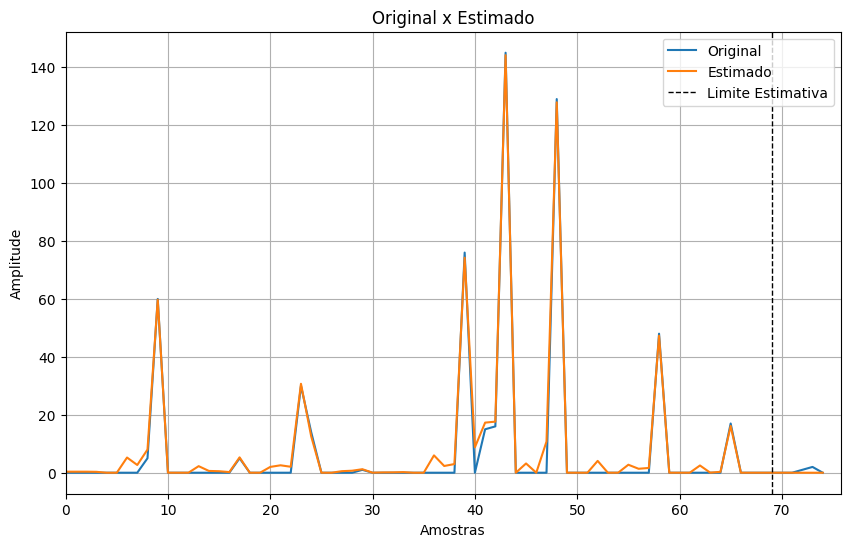

In [ ]:
# lim_filter = len(leituras_canais[canal][enum]) - amostras_por_leitura + 1
# lim_filter = 149 - 75 + 1 = 75
plot_estimado_x_original(sinais_originais[ind], s_reconstruido, limite_filtro=True)

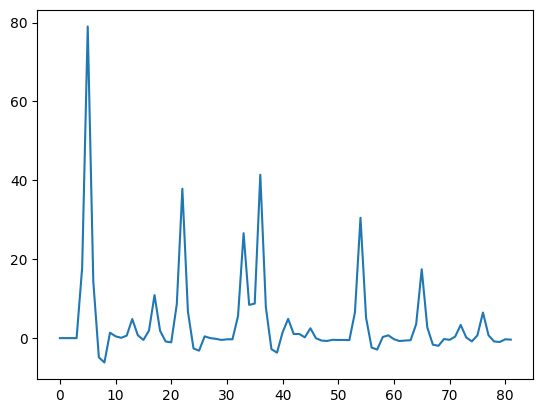

In [ ]:
uma_leitura = leituras_canais["canal_0"][0]
# (uma_leitura)
plt.plot(uma_leitura)

In [ ]:
# Aplicar peso e bias nos sinais reconstruidos e comparar com os devidos sinais originais

# Peso com base no Shaper perfeito

P2) Filtro so com base no canal ideal 
1. Calcular peso so com canal ideal
2. Aplicar esses pesos em todos os canais

# Testes

In [ ]:
leituras_canais = {}
# leituras_canais = {
#     f"canal_{canal+1}":
#         conv(sinais_originais[sinal], waves_por_canal[canal])
#         for sinal in range(len(sinais_originais))
#     for canal in range(qntd_canais)
# }

for canal in range(qntd_canais):
    leituras_canais[f"canal_{canal}"] = []
    for sinal in range(len(sinais_originais)):
        aux = conv(sinais_originais[sinal], waves_por_canal[canal])
        leituras_canais[f"canal_{canal}"].append(aux)

In [ ]:
leituras_canais = {}
leituras_canais = {
    "canal_1": [
        conv(sinais_originais[0], waves_por_canal[0]),
        conv(sinais_originais[1], waves_por_canal[0]),
        conv(sinais_originais[2], waves_por_canal[0]),
    ],
    "canal_2": [
        conv(sinais_originais[0], waves_por_canal[1]),
        conv(sinais_originais[1], waves_por_canal[1]),
        conv(sinais_originais[2], waves_por_canal[1]),
    ],
    "canal_3": [
        conv(sinais_originais[0], waves_por_canal[2]),
        conv(sinais_originais[1], waves_por_canal[2]),
        conv(sinais_originais[2], waves_por_canal[2]),
    ],
}

In [ ]:
len(leituras_canais["canal_1"])

In [ ]:
conv(sinais_originais[0], waves_por_canal[0])

In [ ]:
import numpy as np

mtz3 = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12],
    [13, 14, 15],
    [16, 17, 18],
]
# 1. Permutar um array existente
# [10, 20, 30, 40, 50]
arr = np.array(mtz3)
embaralhado3 = np.random.permutation(arr)
print(embaralhado3)  # Ex: [30 10 50 20 40]
print("\n", arr)  # Original permanece: [10 20 30 40 50]

# 2. Gerar uma permutação de inteiros (0 a n-1)
sequencia = np.random.permutation(5)
# print(sequencia)  # Ex: [2 0 4 1 3]

In [ ]:
divisao3 = int(len(embaralhado3) / qntd_canais)
terco1 = embaralhado3[:divisao3]
terco2 = embaralhado3[divisao3 : divisao3 * 2]
terco3 = embaralhado3[divisao3 * 2 :]
terco3

In [ ]:
mtz = [
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [10, 11, 12],
    [13, 14, 15],
    [16, 17, 18],
    [19, 20, 21],
    [22, 23, 24],
    [25, 26, 27],
]

# matriz = np.arange(36).reshape(12, 3)
matriz = np.arange(4 * 3 * 3).reshape(12, 3)
indx_matriz_embaralhada = np.random.permutation(len(matriz))

div4 = int(len(matriz) / 4)
q1 = matriz[:div4]
q2 = matriz[div4 : div4 * 2]
q3 = matriz[div4 * 2 : div4 * 3]
q4 = matriz[div4 * 3 :]
q4

In [ ]:
indices = [0, 1, 2]
# np.random.permutation(len(sinais_originais))
embaralhado3[indices]

In [ ]:
print(indx_matriz_embaralhada)

indices = indx_matriz_embaralhada.reshape(4, div4)
indices

In [ ]:
waves_por_canal, waves_por_canal[0]

In [ ]:
# lista de indice para cada linha d sinal_original permutado
indices_permutados = np.random.permutation(len(sinais_originais))

# len(sinais_originais) == len(qntd_canais * qntd_leitura_por_canal)
divisao = int(len(sinais_originais) / qntd_canais)  # sempre será divisível

matriz_indices = indices_permutados.reshape(qntd_canais, divisao)

In [ ]:
"""modelo:
y = x * h + n

y = sinal_estimado
x = sinal_original
h = canais
n = ruido
gi = filtro
x_hat = (x * hi) * gi
"""

x = sinais_originais[3]
yi = []
for i in range(qntd_canais):
    hi = waves_por_canal[i]
    yi.append(np_conv(x, hi, mode="full"))
# len(yi) == 149

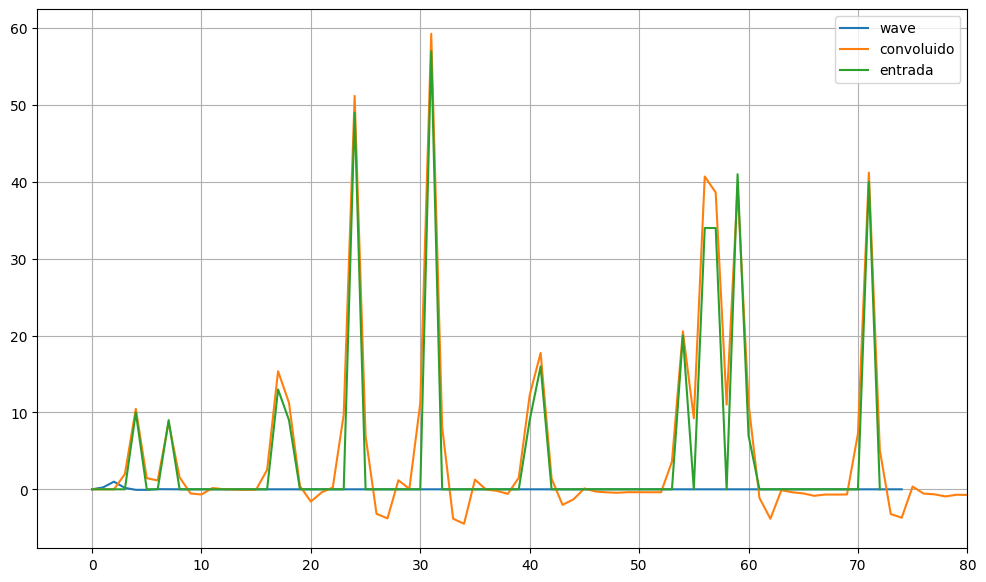

In [106]:
plt.figure(figsize=(12, 7))
plt.xlim(-5, 80)
plt.plot(waves_por_canal[2])
plt.plot(yi[1][2:])
plt.plot(x[:-2])
plt.grid()
plt.legend(["wave", "convoluido", "entrada"])